In [4]:
import sys
import os

# Always anchor relative to THIS file's location
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    #sys.path.insert(0, src_path)

import numpy as np
import torch
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from vqe import cost_function
from ml_model import VQEModel

src = os.path.join(project_root, "src")

scripts = ["data_generation.py", "ml_model.py"]

for script in scripts:
    path = os.path.join(src, script)
    result = subprocess.run(["python", path])
    
    if result.returncode != 0:
        print(f"{script} failed!")
        break

#!python src_path/data_generation.py
#!python ../src/ml_model.py


Loaded dataset from: /media/abdu924/Material/shared/Work_space/Quantum_Projects/vqe-ml-h2/src/../data/vqe_dataset.npy
Epoch 0, Loss: 20.04996681213379
Epoch 20, Loss: 5.800461292266846
Epoch 40, Loss: 3.3956799507141113
Epoch 60, Loss: 2.5325112342834473
Epoch 80, Loss: 1.9986779689788818
Epoch 100, Loss: 1.6631335020065308
Epoch 120, Loss: 1.4610815048217773
Epoch 140, Loss: 1.3890089988708496
Epoch 160, Loss: 1.3437646627426147
Epoch 180, Loss: 1.3090389966964722
Epoch 200, Loss: 1.2776236534118652
Epoch 220, Loss: 1.2488105297088623
Epoch 240, Loss: 1.2206236124038696
Epoch 260, Loss: 1.1920711994171143
Epoch 280, Loss: 1.1628785133361816
Epoch 300, Loss: 1.1334052085876465
Epoch 320, Loss: 1.1044211387634277
Epoch 340, Loss: 1.0737555027008057
Epoch 360, Loss: 1.0389509201049805
Epoch 380, Loss: 1.004237174987793
Epoch 400, Loss: 0.970268964767456
Epoch 420, Loss: 0.9389262199401855
Epoch 440, Loss: 0.9088287353515625
Epoch 460, Loss: 0.8785364627838135
Epoch 480, Loss: 0.847986400

NameError: name 'subprocess' is not defined

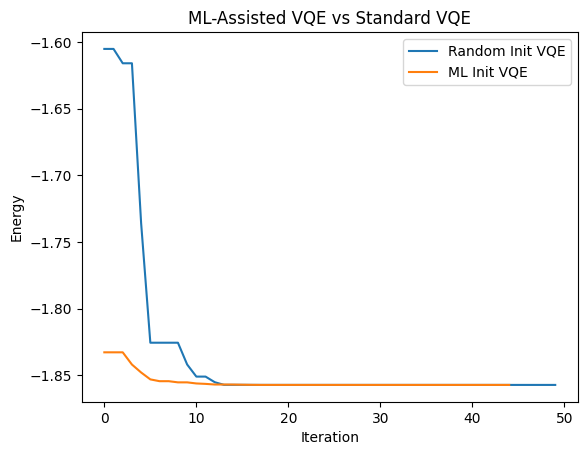

In [15]:
# -------------------------
# Load trained ML model
# -------------------------
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
MODEL_PATH = PROJECT_ROOT / "data" / "vqe_model.pth"
model = VQEModel()
model.load_state_dict(torch.load(MODEL_PATH))

#model.load_state_dict(torch.load("data/vqe_model.pth"))
model.eval()

# -------------------------
# Helper: run VQE
# -------------------------

def run_vqe(theta_init):

    energies = []

    def callback(xk):
        e = cost_function(xk)
        energies.append(e)

    result = minimize(
        cost_function,
        theta_init,
        method="COBYLA",
        callback=callback
    )

    return energies


# -------------------------
# 1. Baseline VQE
# -------------------------

theta_random = np.random.uniform(0, 2*np.pi, 4)

baseline_energies = run_vqe(theta_random)


# -------------------------
# 2. ML-assisted VQE
# -------------------------

theta_input = torch.tensor(theta_random, dtype=torch.float32)

with torch.no_grad():
    theta_ml = model(theta_input).numpy()

ml_energies = run_vqe(theta_ml)


# -------------------------
# Plot comparison
# -------------------------

plt.plot(baseline_energies, label="Random Init VQE")
plt.plot(ml_energies, label="ML Init VQE")

plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("ML-Assisted VQE vs Standard VQE")
plt.legend()

plt.show()